In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
applications = pd.read_csv(
    "../data/applications_cleaned.csv",
    low_memory=False
)
branches = pd.read_csv("../data/branches_cleaned.csv")

In [3]:
applications.columns.tolist()

['Application_ID',
 'Loan_ID',
 'Customer_ID',
 'Application_Date',
 'Approval_Date',
 'Loan_Purpose',
 'Source_Channel',
 'Processing_Fee',
 'Approval_Status',
 'Rejection_Reason']

In [5]:
rejected_apps = applications[
    applications['Approval_Status'].str.lower() == 'rejected'
].copy()

In [8]:
branch_rejections = rejected_apps.groupby('Rejection_Reason').size().sort_values(ascending=False)
branch_rejections.head()

Rejection_Reason
Low Credit Score        4297
Incomplete Documents    4204
Insufficient Income     4099
dtype: int64

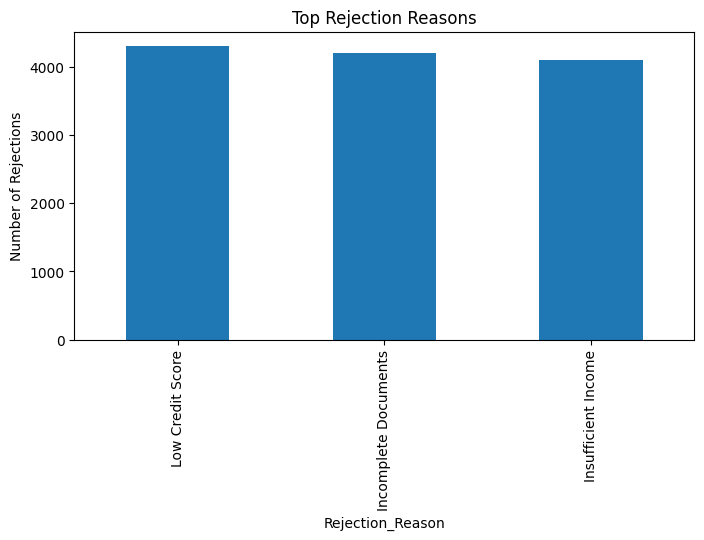

In [10]:
branch_rejections.head(10).plot(kind='bar', figsize=(8,4))
plt.title("Top Rejection Reasons")
plt.ylabel("Number of Rejections")
plt.show()

In [11]:
branches['Efficiency_Score'] = 1 - (
    branches['Delinquent_Loans'] / branches['Total_Active_Loans']
)

In [12]:
branches[['Branch_ID', 'Region', 'Efficiency_Score']].sort_values(
    by='Efficiency_Score',
    ascending=False
).head()

,Branch_ID,Region,Efficiency_Score
39,B040,North,0.994827
29,B030,East,0.990265
46,B047,East,0.985624
26,B027,West,0.978313
45,B046,Central,0.973908


### Task 15 – Branch Efficiency Insights

- Certain branches and regions exhibit higher rejection volumes
- High rejection rates may indicate stricter or inefficient screening
- Branch efficiency varies significantly across the network
- Reducing delinquency can directly improve branch efficiency scores
- Data-driven performance benchmarking can enhance branch operations